In [1]:
import sys
import os

root_path = os.path.abspath(os.path.join('..'))

if root_path not in sys.path:
    sys.path.append(root_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from src.utils import parse_list, language_bucket, achievement_group

In [4]:
data = pd.read_csv('..//data//processed/steam_games_clean.csv')
data.head(3)

,appID,name,release_date,required_age,price,dlc_count,metacritic_score,achievements,recommendations,supported_languages,...,tags,review_count,review_radio,release_year,num_languages,num_audio_languages,review_score_prc,owners_midpoint,log_owners,game_age
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,0,0,0,[],...,[],0,NaN,2023,0,0,NaN,0.0,0.00000,3
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,0,0,231,['English'],...,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",255,0.988235,2016,1,0,98.823529,10000.0,9.21044,10
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,0,0,0,"['English', 'French', 'German', 'Russian']",...,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...",24,0.875000,2019,4,0,87.500000,10000.0,9.21044,7


COMMERCIAL LINKED SUCCESS

<Axes: xlabel='log_owners', ylabel='Count'>

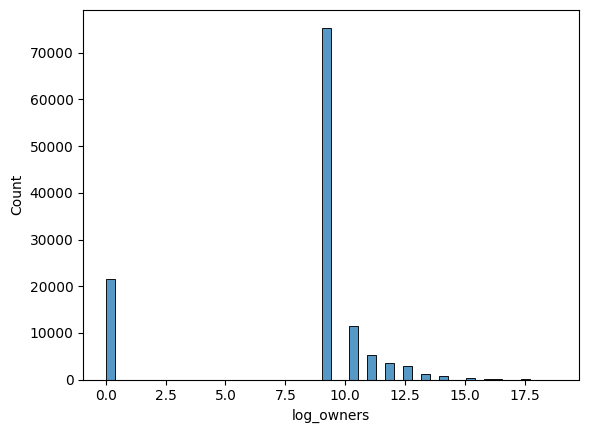

In [ ]:
#Success distribution
sns.histplot(data['log_owners'], bins= 50)

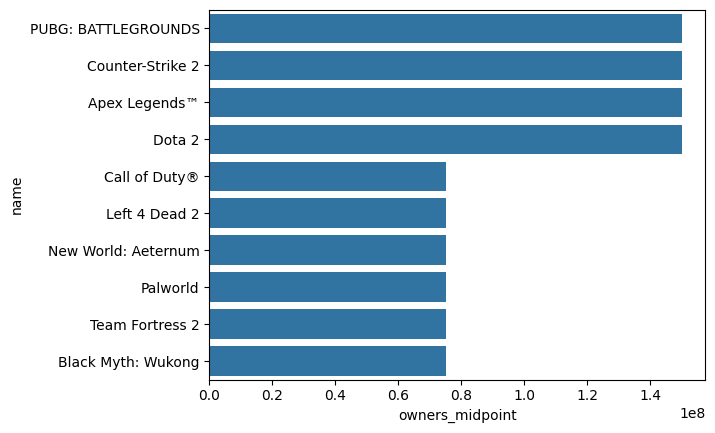

In [ ]:
top10 = (
    data.sort_values('owners_midpoint', ascending=False)
        .head(10)
)

sns.barplot(x="owners_midpoint", y="name", data=top10)
plt.show()

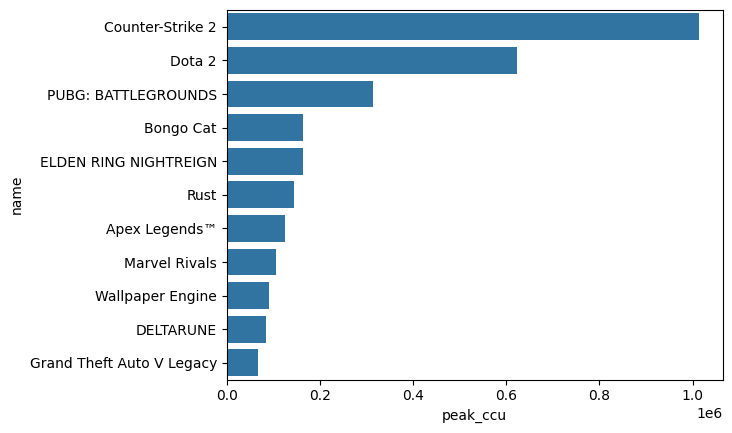

In [ ]:
top10_peakccu = (
    data.sort_values('peak_ccu', ascending=False)
        .head(11)
)

sns.barplot(x="peak_ccu", y="name", data=top10_peakccu)
plt.show()

<Axes: xlabel='review_score_prc', ylabel='log_owners'>

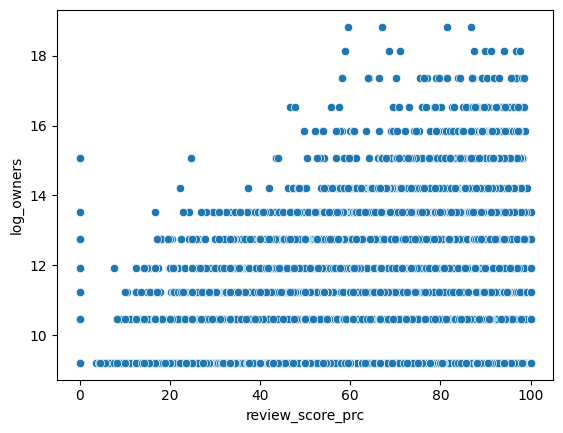

In [ ]:
sns.scatterplot(
    data=data,
    x='review_score_prc',
    y='log_owners'
)

In [ ]:
data['estimated_owners'].value_counts().head(10)

estimated_owners
0 - 20000             75404
0 - 0                 21641
20000 - 50000         11396
50000 - 100000         5355
100000 - 200000        3454
200000 - 500000        2853
500000 - 1000000       1154
1000000 - 2000000       729
2000000 - 5000000       405
5000000 - 10000000      125
Name: count, dtype: int64

<Axes: xlabel='price', ylabel='log_owners'>

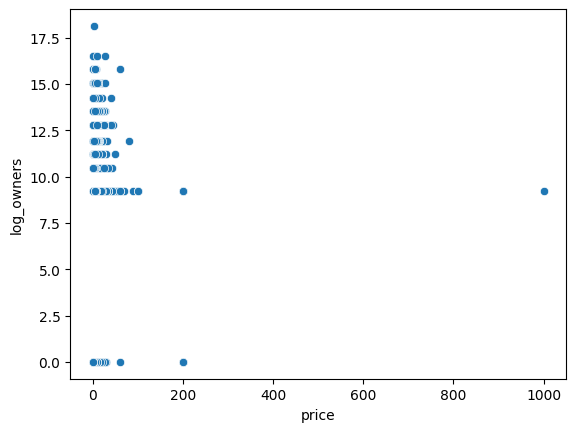

In [ ]:
sns.scatterplot(
    data=data.sample(10000),
    x='price',
    y='log_owners'
)

In [ ]:
data['owners_midpoint'].quantile(
    [0.90, 0.95, 0.99]
)

0.90      75000.0
0.95     150000.0
0.99    1500000.0
Name: owners_midpoint, dtype: float64

In [5]:
success_threshold = data['owners_midpoint'].quantile(0.95)

data['is_successful'] = (
    data['owners_midpoint']
    >= success_threshold
)
data['is_successful'].value_counts(normalize=True)

is_successful
False    0.928106
True     0.071894
Name: proportion, dtype: float64

In [6]:
#What characteristics are associated with belonging to the top 5% best-selling Steam games?
data['genres_list'] = data['genres'].apply(parse_list)
genres_exploded = data.explode('genres_list')
genres_exploded = genres_exploded.drop(columns=['genres'])

In [ ]:
genres_exploded[['name', 'genres_list']].head(20)

,name,genres_list
0,Black Dragon Mage Playtest,NaN
1,Supipara - Chapter 1 Spring Has Come!,Adventure
2,Mystery Solitaire The Black Raven,Casual
3,버튜버 파라노이아 - Vtuber Paranoia,Casual
3,버튜버 파라노이아 - Vtuber Paranoia,Indie
3,버튜버 파라노이아 - Vtuber Paranoia,Simulation
4,Maze Quest VR,Action
4,Maze Quest VR,Early Access
5,Agony VR,Action
5,Agony VR,Adventure


In [7]:
genre_count = (
    genres_exploded['genres_list']
    .value_counts()
)

print(genre_count.head(30))

genres_list
Indie                    80630
Casual                   50210
Action                   46220
Adventure                45141
Simulation               24114
Strategy                 22400
RPG                      20972
Free To Play             12172
Early Access             11091
Sports                    4882
Racing                    4079
Massively Multiplayer     2527
Utilities                 1077
Design & Illustration      580
Animation & Modeling       477
Education                  461
Violent                    414
Video Production           339
Game Development           320
Gore                       257
Audio Production           225
Software Training          219
Photo Editing              180
Web Publishing             112
Nudity                      94
Sexual Content              88
Accounting                  30
Movie                        2
Documentary                  1
Episodic                     1
Name: count, dtype: int64


In [8]:
valid_genres = genre_count[
    genre_count >= 500
].index

genre_success = (
    genres_exploded[
        genres_exploded['genres_list'].isin(valid_genres)
    ]
    .groupby('genres_list')['is_successful']
    .mean()
    .sort_values(ascending=False)
)

genre_success

genres_list
Massively Multiplayer    0.180451
RPG                      0.105236
Strategy                 0.099955
Free To Play             0.092836
Action                   0.092622
Simulation               0.082442
Adventure                0.080813
Racing                   0.072567
Sports                   0.065957
Indie                    0.065323
Design & Illustration    0.063793
Utilities                0.063138
Early Access             0.046885
Casual                   0.043975
Name: is_successful, dtype: float64

RPG games are more likely to become commercial hits than Indie or Casual games.

<Axes: ylabel='genres_list'>

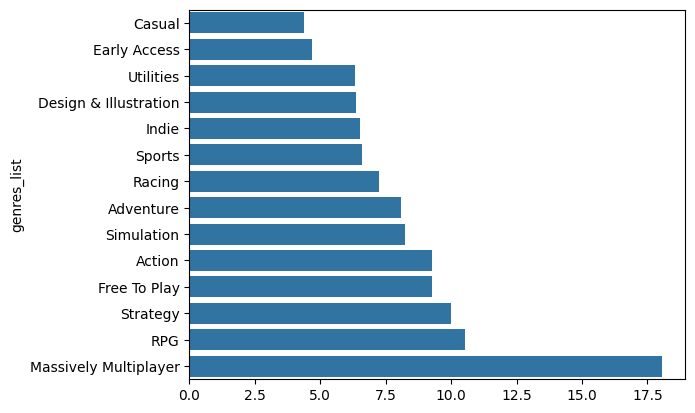

In [9]:
genre_success = (
    genre_success
    .sort_values()
)
sns.barplot(
    x=genre_success.values * 100,
    y=genre_success.index
)

LET'S CONTINUE WITH PRICE SUCCESS
Are expensive games more likely to become commercial hits?

<Axes: xlabel='price', ylabel='log_owners'>

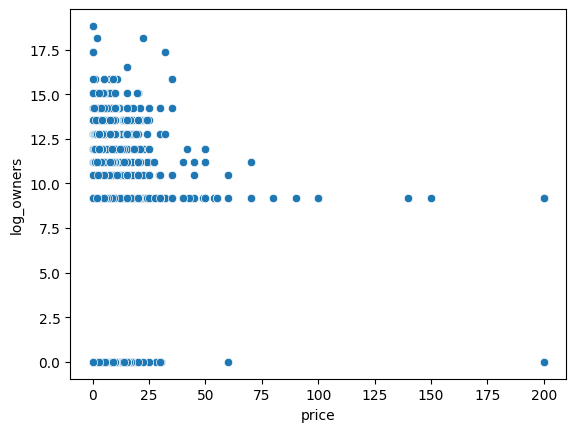

In [ ]:
sns.scatterplot(
    data=data.sample(10000),
    x='price',
    y='log_owners'
)

In [ ]:
data['price'].describe()

count    122611.000000
mean          4.765091
std          12.531030
min           0.000000
25%           0.550000
50%           2.240000
75%           5.240000
max         999.980000
Name: price, dtype: float64

In [ ]:
data['price_range'].value_counts().sort_index()

price_range
Free     26206
0-5      65400
5-10     19240
10-20     9292
20-40     1719
40-60      359
60+        395
Name: count, dtype: int64

In [ ]:
data.groupby('price_range')['is_successful'].agg(
    ['mean', 'count']
)

,mean,count
price_range,,
Free,0.058269,26206
0-5,0.066300,65400
5-10,0.083732,19240
10-20,0.108588,9292
20-40,0.164631,1719
40-60,0.114206,359
60+,0.020253,395


In [10]:
price_bins = [
    -0.01,
    0,
    5,
    10,
    20,
    40,
    60,
    np.inf
]

price_labels = [
    'Free',
    '0-5',
    '5-10',
    '10-20',
    '20-40',
    '40-60',
    '60+'
]

data['price_range'] = pd.cut(
    data['price'],
    bins=price_bins,
    labels=price_labels
)

In [11]:
price_success = (
    data
    .groupby('price_range')['is_successful']
    .mean()
    .sort_index()
)

<Axes: xlabel='price_range'>

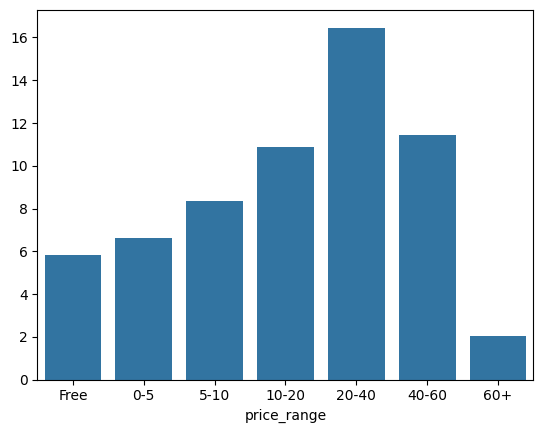

In [ ]:
sns.barplot(
    x=price_success.index,
    y=price_success.values * 100
)

Games priced between $20 and $40 show the highest probability of becoming commercial hits on Steam. Very cheap games are less likely to reach top-selling status, possibly due to the large number of small indie and low-budget releases in that segment. On the other hand, very expensive games ($60+) also show lower success rates. This suggests that successful Steam titles tend to occupy a middle ground: expensive enough to signal production value, but still accessible to a broad audience.

Does the number of supported languages increase the probability of success?

In [12]:
#Define a range of languages which are provided (not audio)
data['language_group'] = data['num_languages'].apply(language_bucket)

language_success = (
    data
    .groupby('language_group')
    ['is_successful']
    .mean()
)

language_success = language_success.sort_values(ascending= True)
language_success

language_group
1        0.042365
2-5      0.050588
20+      0.063433
6-10     0.167039
11-20    0.228542
Name: is_successful, dtype: float64

<Axes: xlabel='language_group'>

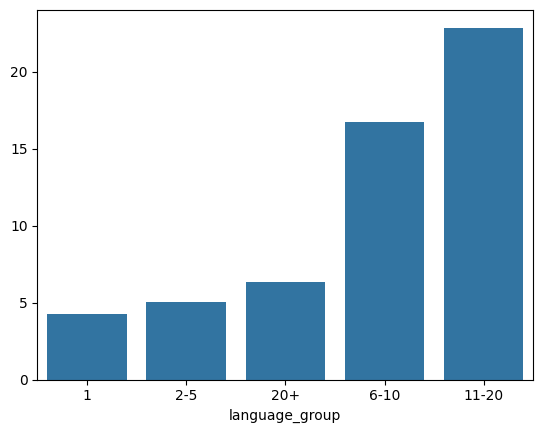

In [ ]:
sns.barplot(
    x = language_success.index,
    y = language_success.values * 100
)

In [ ]:
data['language_group'].value_counts()

language_group
1        59885
2-5      36313
6-10     12991
11-20     8598
20+       4824
Name: count, dtype: int64

In [ ]:
data[data['language_group'] == '20+']['genres'].value_counts()

genres
['Casual', 'Indie']                                                        804
['Casual']                                                                 226
['Casual', 'Indie', 'Strategy']                                            168
['Indie', 'Simulation']                                                    168
['Action', 'Casual', 'Indie']                                              144
                                                                          ... 
['Action', 'Adventure', 'Massively Multiplayer', 'Simulation']               1
['Casual', 'Indie', 'Racing', 'Sports']                                      1
['Casual', 'Audio Production', 'Utilities', 'Video Production']              1
['Adventure', 'Casual', 'Indie', 'Massively Multiplayer', 'Simulation']      1
['Adventure', 'Indie', 'RPG', 'Strategy', 'Early Access']                    1
Name: count, Length: 549, dtype: int64

Supporting multiple languages is strongly associated with commercial success. Games localized into 6–20 languages show substantially higher success rates than games available in only one language. Interestingly, this trend weakens among titles supporting more than 20 languages, likely reflecting differences in the types of games included in that group rather than the effect of localization itself.

#ENGAGEMENT

Which game genres keep players engaged for the longest time?

In [ ]:
data['average_playtime_forever'].describe()

count    1.226110e+05
mean     2.080232e+02
std      1.121768e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.429544e+06
Name: average_playtime_forever, dtype: float64

In [13]:
non_games = [
    'Web Publishing',
    'Video Production',
    'Audio Production',
    'Game Development',
    'Photo Editing',
    'Animation & Modeling',
    'Design & Illustration',
    'Utilities',
    'Software Training',
    'Education',
    'Accounting'
]

In [ ]:
genres_exploded['average_playtime_forever']

0         0
1         8
2         0
3         0
3         0
         ..
122609    0
122609    0
122610    0
122610    0
122610    0
Name: average_playtime_forever, Length: 337731, dtype: int64

In [14]:
playtime_data = genres_exploded[
    (genres_exploded['average_playtime_forever'] > 0)
    &
    (~genres_exploded['genres_list'].isin(non_games))
]
playtime_data['genres_list'].value_counts()

genres_list
Indie                    17270
Action                   11031
Adventure                10848
Casual                    8680
Simulation                6482
RPG                       5941
Strategy                  5842
Early Access              1793
Free To Play              1564
Sports                    1097
Racing                     886
Massively Multiplayer      714
Violent                    136
Gore                        95
Nudity                      40
Sexual Content              37
Movie                        1
Name: count, dtype: int64

In [15]:
genre_playtime = (
    playtime_data
    .explode('genres_list')
    .groupby('genres_list')
    ['average_playtime_forever']
    .median()
    .sort_values(ascending=False)
)

genre_playtime

genres_list
Movie                    418.0
Massively Multiplayer    372.0
RPG                      304.0
Strategy                 294.0
Simulation               238.0
Early Access             222.0
Adventure                219.0
Action                   210.0
Sports                   208.0
Indie                    200.0
Casual                   190.0
Racing                   184.5
Nudity                   163.0
Free To Play             162.0
Sexual Content           147.0
Violent                  118.5
Gore                     117.0
Name: average_playtime_forever, dtype: float64

<Axes: ylabel='genres_list'>

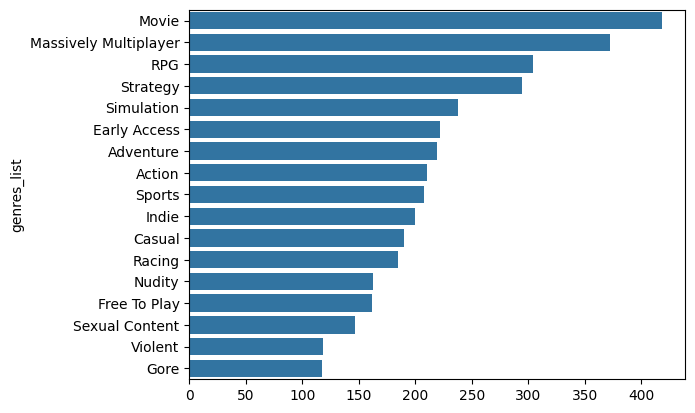

In [ ]:
sns.barplot(
    x = genre_playtime.values,
    y = genre_playtime.index
)

Do achievements increase playtime?

In [ ]:
data['achievements'].describe()

count    122611.000000
mean         18.087015
std         141.493879
min           0.000000
25%           0.000000
50%           2.000000
75%          19.000000
max        9821.000000
Name: achievements, dtype: float64

In [16]:
data['achievement_group'] = data['achievements'].apply(achievement_group)

data['achievement_group'].value_counts()

achievement_group
0         59572
11-25     23666
1-10      17658
26-50     14535
51-100     6158
100+       1022
Name: count, dtype: int64

<Axes: ylabel='achievement_group'>

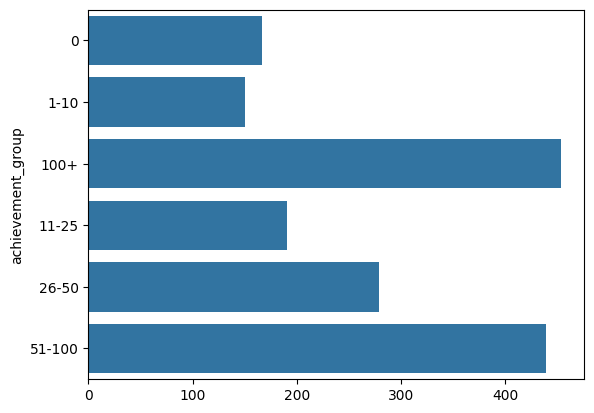

In [17]:
playtime_data = data[data['average_playtime_forever'] > 0]

playtime_by_achievments = playtime_data.groupby('achievement_group')['average_playtime_forever'].median()

sns.barplot(
    x = playtime_by_achievments.values,
    y = playtime_by_achievments.index
)

Games with more achievements tend to be associated with longer player engagement. This does not imply causation, since longer and more complex games may naturally include more achievements.

#SATISFACTION

Does playtime correlate with review scores?

In [20]:
data.columns

Index(['appID', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'metacritic_score', 'achievements', 'recommendations',
       'supported_languages', 'full_audio_languages', 'developers',
       'publishers', 'categories', 'genres', 'user_score', 'positive',
       'negative', 'estimated_owners', 'average_playtime_forever',
       'average_playtime_2weeks', 'peak_ccu', 'tags', 'review_count',
       'review_radio', 'release_year', 'num_languages', 'num_audio_languages',
       'review_score_prc', 'owners_midpoint', 'log_owners', 'game_age',
       'is_successful', 'genres_list', 'achievement_group'],
      dtype='str')

In [21]:
data['review_score_prc'].value_counts()

review_score_prc
100.000000    15533
50.000000      2767
0.000000       2610
66.666667      2263
75.000000      1660
              ...  
94.146341         1
89.809445         1
90.829694         1
84.666667         1
71.466578         1
Name: count, Length: 17957, dtype: int64

In [18]:
global_mean = data['review_score_prc'].mean()
global_mean

np.float64(75.8275960631426)

In [19]:
m = 100

data['weighted_score'] = (
    (data['review_count'] * data['review_score_prc']
     + m * global_mean)
    /
    (data['review_count'] + m)
)

data['weighted_score'].value_counts().sort_values(ascending=False)

weighted_score
76.066927    3569
76.301565    2352
76.531647    1748
75.076828    1644
76.757304    1309
             ... 
88.140195       1
89.433690       1
86.269786       1
81.131038       1
71.606939       1
Name: count, Length: 23389, dtype: int64

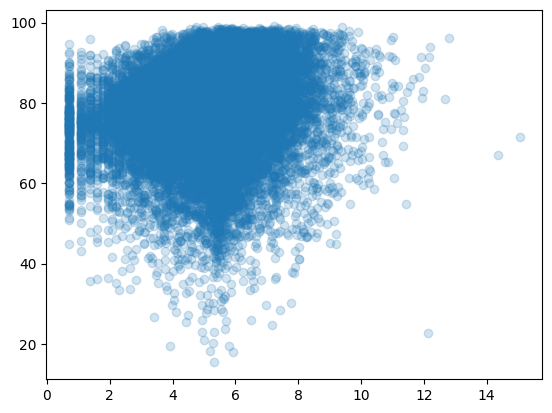

In [20]:
review_data = data[data['average_playtime_forever'] > 0]

plt.scatter(
    np.log1p(review_data['average_playtime_forever']),
    review_data['weighted_score'],
    alpha=0.2
)

In [21]:
review_data[
    ['average_playtime_forever',
     'weighted_score']
].corr()

,average_playtime_forever,weighted_score
average_playtime_forever,1.000000,0.000452
weighted_score,0.000452,1.000000


Players do not necessarily rate a game better simply because they spend more time playing it.

Which tags receive the best review scores?

In [24]:
data['tags'].head()

0                                                   []
1    {'Adventure': 27, 'Visual Novel': 19, 'Anime':...
2    {'Casual': 83, 'Card Game': 52, 'Solitaire': 4...
3                                                   []
4                                                   []
Name: tags, dtype: str

In [25]:
import ast

data['tags_dict'] = data['tags'].apply( lambda x: ast.literal_eval(x) if x != '[]' else {}) 

data['tags_list'] = data['tags_dict'].apply(
    lambda d: list(d.keys())
)

In [33]:
tags_exploded = data.explode('tags_list')

tag_counts = tags_exploded['tags_list'].value_counts()


valid_tags = tag_counts[tag_counts >= 1000].index

len(valid_tags)

215

In [31]:
all_tags = tags_exploded['tags_list'].dropna().unique()
len(all_tags)

452

In [38]:
review_data = data[data['review_count'] >= 100]

tags_exploded = review_data.explode('tags_list')

tag_counts = tags_exploded['tags_list'].value_counts()

valid_tags = tag_counts[tag_counts >= 1000].index

tag_scores = (
    tags_exploded[
        tags_exploded['tags_list'].isin(valid_tags)
    ]
    .groupby('tags_list')['weighted_score']
    .mean()
    .sort_values(ascending=False)
)

tag_scores

tags_list
Romance             84.345882
Cute                84.209109
Hand-drawn          84.177360
Visual Novel        84.071811
Multiple Endings    83.398540
                      ...    
Realistic           76.538078
Crafting            76.471181
Survival            76.066428
PvP                 75.996488
Early Access        75.964681
Name: weighted_score, Length: 94, dtype: float64

In [39]:
tag_summary = (
    tags_exploded[
        tags_exploded['tags_list'].isin(valid_tags)
    ]
    .groupby('tags_list')
    .agg(
        avg_score=('weighted_score', 'mean'),
        count=('tags_list', 'size')
    )
    .sort_values('avg_score', ascending=False)
)
tag_summary

,avg_score,count
tags_list,,
Romance,84.345882,1057
Cute,84.209109,3559
Hand-drawn,84.177360,1207
Visual Novel,84.071811,2191
Multiple Endings,83.398540,1741
...,...,...
Realistic,76.538078,1898
Crafting,76.471181,1263
Survival,76.066428,2247


In [41]:
best_tags = (
    tag_summary
    .sort_values('avg_score', ascending=False)
    .head(10)
)

worst_tags = (
    tag_summary
    .sort_values('avg_score', ascending=True)
    .head(10)
)

display(best_tags)
worst_tags

,avg_score,count
tags_list,,
Romance,84.345882,1057
Cute,84.209109,3559
Hand-drawn,84.177360,1207
Visual Novel,84.071811,2191
Multiple Endings,83.398540,1741
Great Soundtrack,83.334426,3032
Comedy,83.288511,2209
Drama,83.012599,1135
Pixel Graphics,82.949183,3521


,avg_score,count
tags_list,,
Early Access,75.964681,2599
PvP,75.996488,1606
Survival,76.066428,2247
Crafting,76.471181,1263
Realistic,76.538078,1898
Open World,76.635934,2882
FPS,77.136075,2027
Sports,77.148092,1023
Multiplayer,77.321524,5200


In [42]:
tag_summary.sort_values(
    'count',
    ascending=False
).head(20)

,avg_score,count
tags_list,,
Singleplayer,80.570168,14863
Indie,79.168866,12665
Adventure,79.737667,10832
Action,78.228833,10434
Casual,80.146359,8172
2D,82.627153,6737
Simulation,77.797661,6032
Atmospheric,80.957245,5848
RPG,78.611367,5782


Tags associated with narrative and artistic experiences tend to receive the highest user ratings, while competitive and multiplayer-oriented tags receive lower ratings on average.

In [43]:
data.to_csv(
    '../data/processed/steam_dashboard.csv',
    index=False
)

In [44]:
data.columns

Index(['appID', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'metacritic_score', 'achievements', 'recommendations',
       'supported_languages', 'full_audio_languages', 'developers',
       'publishers', 'categories', 'genres', 'user_score', 'positive',
       'negative', 'estimated_owners', 'average_playtime_forever',
       'average_playtime_2weeks', 'peak_ccu', 'tags', 'review_count',
       'review_radio', 'release_year', 'num_languages', 'num_audio_languages',
       'review_score_prc', 'owners_midpoint', 'log_owners', 'game_age',
       'is_successful', 'genres_list', 'price_range', 'language_group',
       'achievement_group', 'weighted_score', 'tags_dict', 'tags_list'],
      dtype='str')